# *Import Libraries*

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import zipfile
from google.colab import drive

# *Dataset Path*

In [ ]:
# *** Step 1: Mount Drive and Extract Road Damage Dataset
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define paths
zip_path = '/content/drive/MyDrive/DEEP LEARNING /dataset.zip'
extract_path = '/content/drive/MyDrive/DEEP LEARNING'

# Extract the dataset
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete! Folder content:")
print(os.listdir(extract_path))

✅ Extraction complete! Folder content:
['README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']


# *Data Preprocessing*
Image Preprocessing + Data Augmentation


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_path = os.path.join(extract_path, "train")
valid_path = os.path.join(extract_path, "valid")
test_path = os.path.join(extract_path, "test")

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 6925 images belonging to 2 classes.
Found 989 images belonging to 2 classes.
Found 1977 images belonging to 2 classes.


# *Build CNN Model*

In [ ]:
model = Sequential()

# Input Layer for explicit input shape definition
model.add(Input(shape=(128,128,3)))

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Batch Normalization
model.add(BatchNormalization())

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# *Experiment 1 → Adam*

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#train Model

history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=30
)



Epoch 1/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 120s 399ms/step - accuracy: 0.5281 - loss: 0.8599 - val_accuracy: 0.5035 - val_loss: 0.6927
Epoch 2/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 79s 363ms/step - accuracy: 0.5574 - loss: 0.6866 - val_accuracy: 0.5086 - val_loss: 0.6871
Epoch 3/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 77s 355ms/step - accuracy: 0.5523 - loss: 0.6860 - val_accuracy: 0.5642 - val_loss: 0.6790
Epoch 4/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 75s 345ms/step - accuracy: 0.6062 - loss: 0.6654 - val_accuracy: 0.6360 - val_loss: 0.6501
Epoch 5/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 75s 344ms/step - accuracy: 0.6214 - loss: 0.6501 - val_accuracy: 0.6562 - val_loss: 0.6345
Epoch 6/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 74s 339ms/step - accuracy: 0.6468 - loss: 0.6359 - val_accuracy: 0.6471 - val_loss: 0.6356
Epoch 7/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 75s 346ms/step - accuracy: 0.6487 - loss: 0.6334 - val_accuracy: 0.6400 - val_loss: 0.6223
Epoch 8/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 74s 342ms/step - accuracy: 0.6617 - loss: 

In [ ]:
#Evaluate Model
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.7921 - loss: 0.4789
Test Loss: 0.4789072275161743
Test Accuracy: 0.7921092510223389


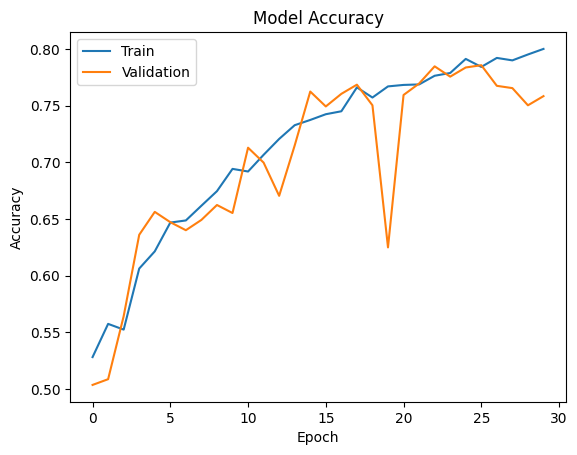

In [ ]:
#Accuracy Visualization
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

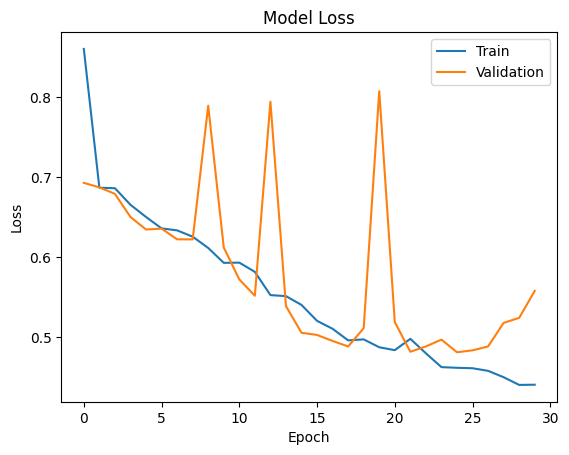

In [ ]:
#Loss Visualization
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

# *Experiment 2 → SGD*

In [ ]:
model2 = Sequential()

# Input Layer for explicit input shape definition
model2.add(Input(shape=(128,128,3)))

model2.add(Conv2D(
    32,
    (3,3),
    activation='relu'
))

model2.add(MaxPooling2D(pool_size=(2,2)))

model2.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model2.add(MaxPooling2D(pool_size=(2,2)))


model2.add(Flatten())

model2.add(Dense(128, activation='relu'))

model2.add(Dropout(0.3))

model2.add(Dense(1, activation='sigmoid'))

In [ ]:
model2.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#train Model

history2 = model2.fit(
    train_data,
    validation_data=valid_data,
    epochs=30
)

Epoch 1/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 72s 321ms/step - accuracy: 0.5441 - loss: 0.6878 - val_accuracy: 0.5905 - val_loss: 0.6806
Epoch 2/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 68s 312ms/step - accuracy: 0.5672 - loss: 0.6789 - val_accuracy: 0.5167 - val_loss: 0.6971
Epoch 3/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 70s 321ms/step - accuracy: 0.5860 - loss: 0.6712 - val_accuracy: 0.5996 - val_loss: 0.6670
Epoch 4/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 69s 316ms/step - accuracy: 0.6022 - loss: 0.6643 - val_accuracy: 0.6138 - val_loss: 0.6494
Epoch 5/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 73s 339ms/step - accuracy: 0.6121 - loss: 0.6558 - val_accuracy: 0.6208 - val_loss: 0.6436
Epoch 6/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 68s 313ms/step - accuracy: 0.6182 - loss: 0.6504 - val_accuracy: 0.5763 - val_loss: 0.6773
Epoch 7/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 69s 316ms/step - accuracy: 0.6277 - loss: 0.6449 - val_accuracy: 0.6734 - val_loss: 0.6250
Epoch 8/30
217/217 ━━━━━━━━━━━━━━━━━━━━ 68s 315ms/step - accuracy: 0.6351 - loss: 0

In [ ]:
#Evaluate Model
test_loss2, test_accuracy2 = model2.evaluate(test_data)

print("Test Loss:", test_loss2)
print("Test Accuracy:", test_accuracy2)

62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 0.7643 - loss: 0.4856
Test Loss: 0.48564282059669495
Test Accuracy: 0.7642893195152283


# *Comparison Table*

In [ ]:
print("Experiment 1 (Adam)")
print("Accuracy:", test_accuracy)
print("Loss:", test_loss)

print("-------------------")

print("Experiment 2 (SGD)")
print("Accuracy:", test_accuracy2)
print("Loss:", test_loss2)

Experiment 1 (Adam)
Accuracy: 0.7921092510223389
Loss: 0.4789072275161743
-------------------
Experiment 2 (SGD)
Accuracy: 0.7642893195152283
Loss: 0.48564282059669495


# *Save Model*

In [ ]:
model.save("cats_vs_dogs_model.h5")

# *Results*

In [ ]:
results = pd.DataFrame({
    'Model': ['Adam', 'SGD'],
    'Accuracy': [test_accuracy, test_accuracy2],
    'Loss': [test_loss, test_loss2]
})

print(results)

  Model  Accuracy      Loss
0  Adam  0.792109  0.478907
1   SGD  0.764289  0.485643


# *Model Summary*


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,177,861 (84.60 MB)

 Trainable params: 7,392,577 (28.20 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 14,785,156 (56.40 MB)